# Caltech_USCD Birds 200 (CUB 200)
- 조류 분류 연구를 위해 만들어진 이미지 데이터셋
- 클래스 수 : 200종의 새 이미지
- 이미지 수 : 약 6000장 (각 60장 정도 있음)

In [1]:
import pathlib
import cv2 as cv
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator as imgen
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D,Flatten , Dropout,BatchNormalization , GlobalAveragePooling2D

In [2]:
data_dir = pathlib.Path('dataset/CUB_200_2011/images')
img_size = (244,244)
batch_size = 32
num_classes = 200

In [3]:
# 학습용 데이터 : 데이터 증강 , 정규화
train_gen_aug = imgen(rescale=1/255. ,horizontal_flip = True,
                 rotation_range=35, zoom_range = 0.2,
                 validation_split = 0.2) # 전체 중 20%를 검증용으로 분

# 검증용 데이터 : 정규화
valid_gen = imgen(rescale=1/255. , validation_split=0.2)

In [4]:
train_data_aug = train_gen_aug.flow_from_directory(
    data_dir, 
    batch_size = batch_size , 
    target_size = img_size , 
    class_mode = 'sparse',      # 정수 레이블 (200개 클래스)
    subset = 'training' ,       # 학습용(80%)
    seed = 200
)

valid_data = valid_gen.flow_from_directory(
    data_dir, 
    batch_size = batch_size , 
    target_size = img_size , 
    class_mode = 'sparse',      # 정수 레이블 (200개 클래스)
    subset = 'validation' ,       # 학습용(80%)
    seed = 200
)

Found 9465 images belonging to 200 classes.
Found 2323 images belonging to 200 classes.


In [5]:
model = Sequential()

model.add(Conv2D(32,3,padding='same',activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D())
model.add(Conv2D(64,3,padding='same',activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(128,3,padding='same',activation='relu'))
model.add(MaxPooling2D())

# model.add(Flatten())
model.add(GlobalAveragePooling2D())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(num_classes , activation='softmax'))

In [6]:
model.compile(optimizer='adam' , loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [7]:
callback_01 = [EarlyStopping(monitor='val_accuracy', patience=5,
                            restore_best_weights=True, verbose=1)]

In [8]:
history = model.fit(train_data_aug, validation_data = valid_data, 
                   epochs=20 , callbacks = callback_01)

Epoch 1/20
296/296 [==============================] - 98s 308ms/step - loss: 5.2651 - accuracy: 0.0052 - val_loss: 5.1642 - val_accuracy: 0.0086
Epoch 2/20
296/296 [==============================] - 81s 273ms/step - loss: 5.1426 - accuracy: 0.0082 - val_loss: 5.0928 - val_accuracy: 0.0103
Epoch 3/20
296/296 [==============================] - 86s 292ms/step - loss: 5.1035 - accuracy: 0.0092 - val_loss: 5.0617 - val_accuracy: 0.0121
Epoch 4/20
296/296 [==============================] - 90s 305ms/step - loss: 5.0615 - accuracy: 0.0104 - val_loss: 5.0190 - val_accuracy: 0.0155
Epoch 5/20
296/296 [==============================] - 90s 305ms/step - loss: 5.0023 - accuracy: 0.0141 - val_loss: 4.9878 - val_accuracy: 0.0172
Epoch 6/20
296/296 [==============================] - 85s 286ms/step - loss: 4.9630 - accuracy: 0.0143 - val_loss: 4.9424 - val_accuracy: 0.0189
Epoch 7/20
296/296 [==============================] - 86s 290ms/step - loss: 4.9333 - accuracy: 0.0188 - val_loss: 4.9040 - val_ac

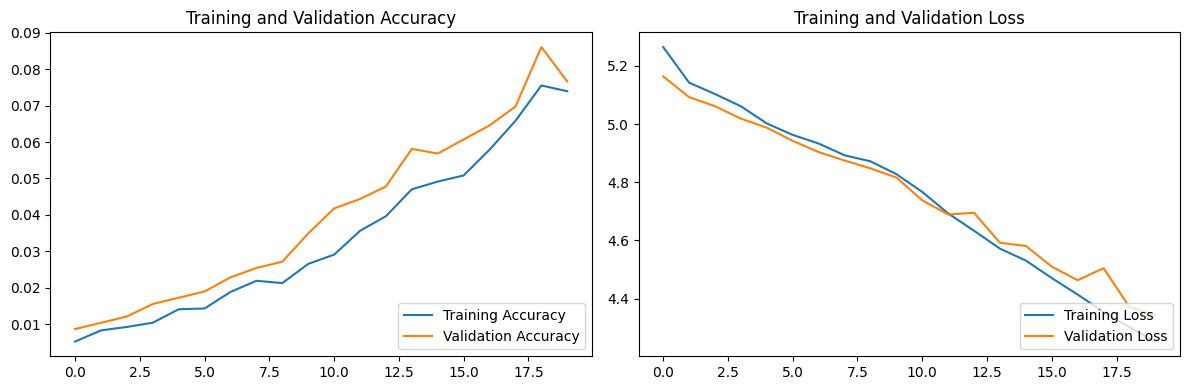

In [9]:
acc_01 = history.history['accuracy']
val_acc_01 = history.history['val_accuracy']
loss_01 = history.history['loss']
val_loss_01 = history.history['val_loss']

epochs_range_01 = np.arange(len(val_loss_01))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs_range_01 , acc_01 , label = 'Training Accuracy')
plt.plot(epochs_range_01 , val_acc_01 , label = 'Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range_01 , loss_01 , label = 'Training Loss')
plt.plot(epochs_range_01 , val_loss_01 , label = 'Validation Loss')
plt.legend(loc='lower right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

## 전이 학습

In [10]:
# 학습용 데이터 : 데이터 증강 , 정규화
train_gen_aug_02 = imgen(preprocessing_function= preprocess_input,
                         horizontal_flip = True,
                         rotation_range=35, 
                         zoom_range = 0.2,
                         validation_split = 0.2) # 전체 중 20%를 검증용으로 분

# 검증용 데이터 : 정규화
valid_gen_02 = imgen(preprocessing_function= preprocess_input, validation_split=0.2)

In [11]:
train_data_aug_02 = train_gen_aug_02.flow_from_directory(
    data_dir, 
    batch_size = batch_size , 
    target_size = img_size , 
    class_mode = 'sparse',      # 정수 레이블 (200개 클래스)
    subset = 'training' ,       # 학습용(80%)
    seed = 200
)

valid_data_02 = valid_gen_02.flow_from_directory(
    data_dir, 
    batch_size = batch_size , 
    target_size = img_size , 
    class_mode = 'sparse',      # 정수 레이블 (200개 클래스)
    subset = 'validation' ,       # 학습용(80%)
    seed = 200
)

Found 9465 images belonging to 200 classes.
Found 2323 images belonging to 200 classes.


In [12]:
base_model = MobileNetV2(input_shape=(244,244,3),
                        include_top=False,
                        weights='imagenet')

base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

# 전이학습 모델

model_02 =Sequential([base_model,
                      GlobalAveragePooling2D(),
                      Dense(256,activation='relu'),
                      Dropout(0.4),
                      Dense(num_classes , activation='softmax')])

In [13]:
model_02.compile(optimizer='adam' , loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [14]:
callback_02 = [EarlyStopping(monitor='val_accuracy', patience=5,
                            restore_best_weights=True, verbose=1)]

In [15]:
history = model_02.fit(train_data_aug_02, validation_data = valid_data_02, 
                   epochs=20 , callbacks = callback_02)

Epoch 1/20
296/296 [==============================] - 90s 298ms/step - loss: 4.2658 - accuracy: 0.0862 - val_loss: 8.6613 - val_accuracy: 0.0581
Epoch 2/20
296/296 [==============================] - 81s 272ms/step - loss: 2.8316 - accuracy: 0.2550 - val_loss: 17.2262 - val_accuracy: 0.0306
Epoch 3/20
296/296 [==============================] - 89s 301ms/step - loss: 2.2253 - accuracy: 0.3749 - val_loss: 18.2336 - val_accuracy: 0.0396
Epoch 4/20
296/296 [==============================] - 99s 335ms/step - loss: 1.8643 - accuracy: 0.4681 - val_loss: 14.9888 - val_accuracy: 0.0508
Epoch 5/20
296/296 [==============================] - 97s 327ms/step - loss: 1.6146 - accuracy: 0.5305 - val_loss: 20.0914 - val_accuracy: 0.0547
Epoch 6/20
296/296 [==============================] - 101s 341ms/step - loss: 1.4559 - accuracy: 0.5723 - val_loss: 12.9124 - val_accuracy: 0.0680
Epoch 7/20
296/296 [==============================] - 101s 341ms/step - loss: 1.3157 - accuracy: 0.6058 - val_loss: 10.4187 

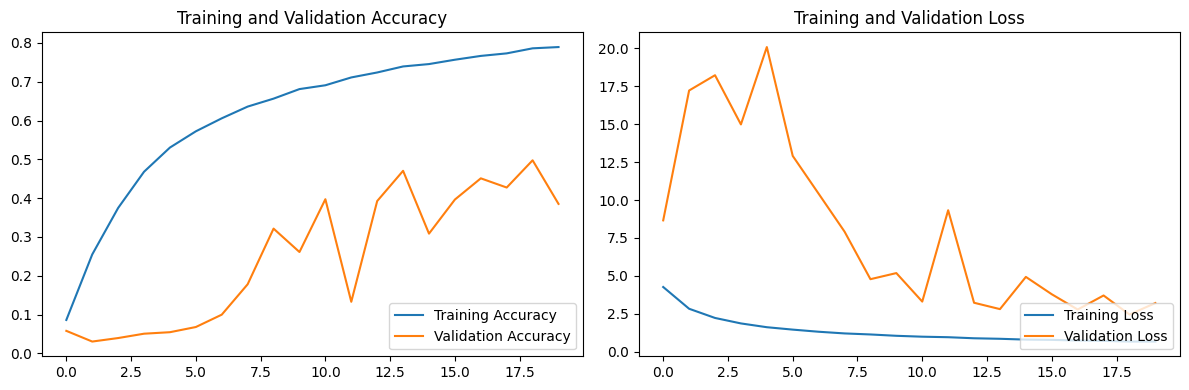

In [16]:
acc_02 = history.history['accuracy']
val_acc_02 = history.history['val_accuracy']
loss_02 = history.history['loss']
val_loss_02 = history.history['val_loss']

epochs_range_02 = np.arange(len(val_loss_02))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs_range_02 , acc_02 , label = 'Training Accuracy')
plt.plot(epochs_range_02 , val_acc_02 , label = 'Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range_02 , loss_02 , label = 'Training Loss')
plt.plot(epochs_range_02 , val_loss_02 , label = 'Validation Loss')
plt.legend(loc='lower right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

In [23]:
from tensorflow.keras.applications.resnet_v2 import preprocess_input

img_path = 'test/test_bird.jpg'
img = image.load_img(img_path, target_size=(244, 244))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

pred = model_02.predict(img_array)
pred_class = np.argmax(pred[0])
confidence = np.max(pred[0]) * 100

print("Predicted class:", pred_class)
print(f"Confidence: {confidence:.2f}%")

1/1 [==============================] - 0s 23ms/step
Predicted class: 135
Confidence: 94.75%
94.754153
